# Census Income Analysis: Fair Income Prediction for Financial Access
End-to-end ML pipeline: <br>
EDA → preprocessing → model training → threshold optimisation → fairness audit → SHAP explainability

### 1. Setup & Data Loading

In [1]:
import warnings, pickle
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline

import xgboost as xgb
import shap
from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                equalized_odds_difference, selection_rate)
from fairlearn.postprocessing import ThresholdOptimizer

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print("All libraries imported successfully.")


All libraries imported successfully.


In [2]:
df = pd.read_csv('adult.csv')
print("Shape:", df.shape)
print()
print(df.dtypes)
df.head()


Shape: (32561, 15)

age               int64
workclass           str
fnlwgt            int64
education           str
education.num     int64
marital.status      str
occupation          str
relationship        str
race                str
sex                 str
capital.gain      int64
capital.loss      int64
hours.per.week    int64
native.country      str
income              str
dtype: object


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


Class distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Class proportions:
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


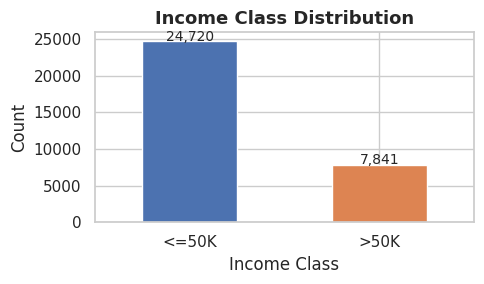

In [3]:
print("Class distribution:")
print(df['income'].value_counts())
print()
print("Class proportions:")
print(df['income'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
df['income'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'], edgecolor='white')
ax.set_title('Income Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Income Class'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x()+p.get_width()/2, p.get_height()+100),
                ha='center', fontsize=10)
plt.tight_layout(); plt.show()


### 2. Exploratory Data Analysis

In [4]:
df.replace(' ?', np.nan, inplace=True)   # strip leading space too
df.replace('?', np.nan, inplace=True)
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])


Missing values per column:
workclass         1836
occupation        1843
native.country     583
dtype: int64


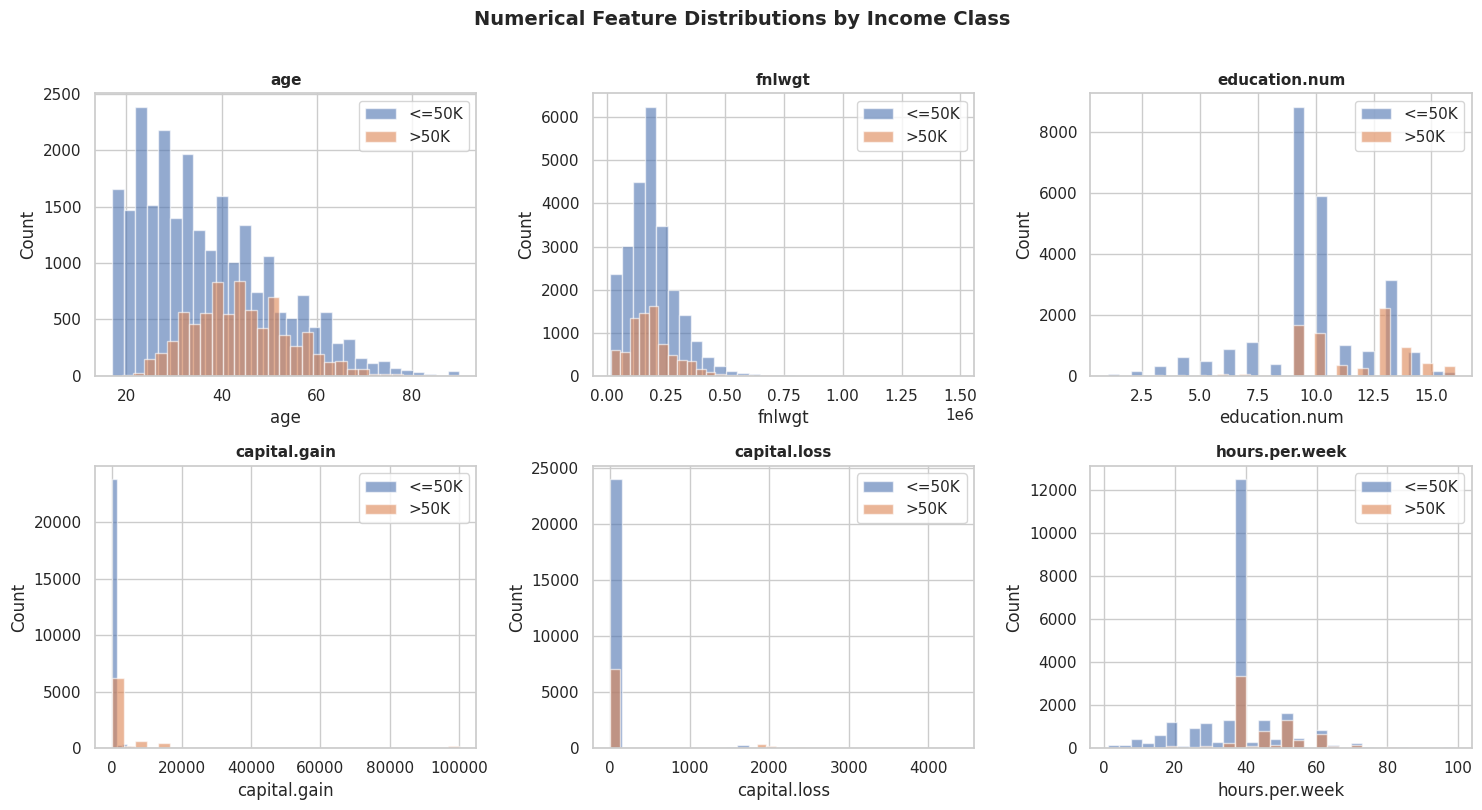

In [5]:
num_cols = ['age','fnlwgt','education.num','capital.gain','capital.loss','hours.per.week']
palette = {'<=50K':'#4C72B0', '>50K':'#DD8452'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for income_class, grp in df.groupby('income'):
        axes[i].hist(grp[col].dropna(), bins=30, alpha=0.6,
                     label=income_class, color=palette[income_class], edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count')
    axes[i].legend()
plt.suptitle('Numerical Feature Distributions by Income Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


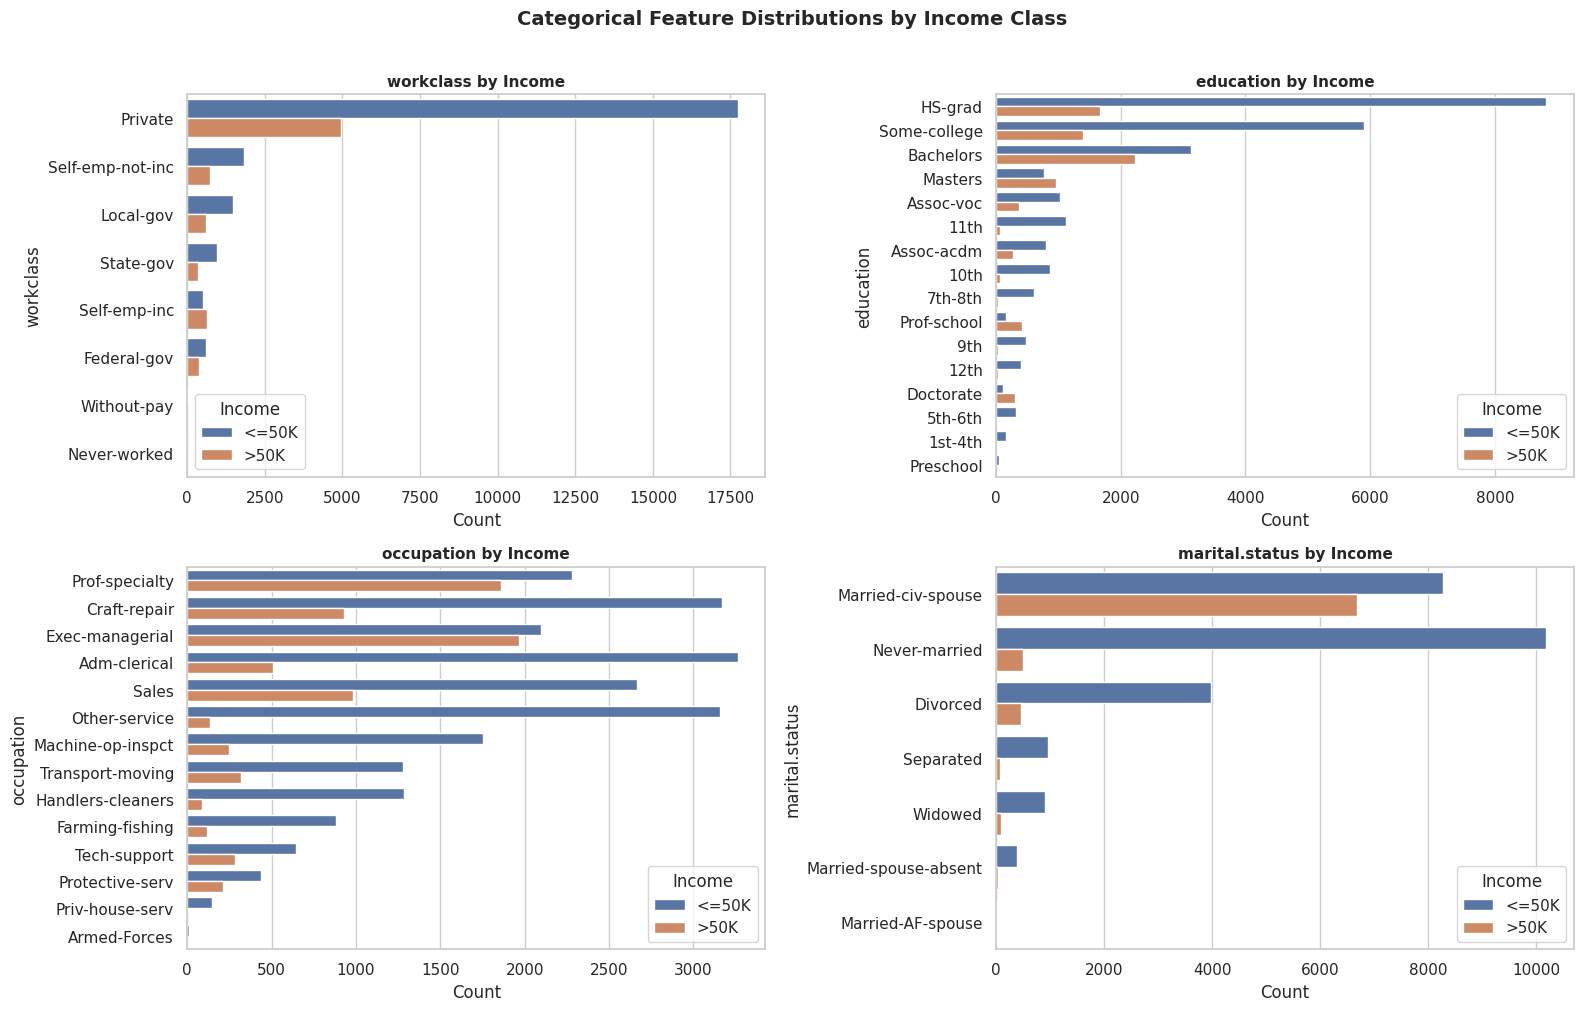

In [6]:
cat_cols = ['workclass','education','occupation','marital.status']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='income', order=order, palette=palette, ax=axes[i])
    axes[i].set_title(f'{col} by Income', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Count'); axes[i].set_ylabel(col)
    axes[i].legend(title='Income')
plt.suptitle('Categorical Feature Distributions by Income Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


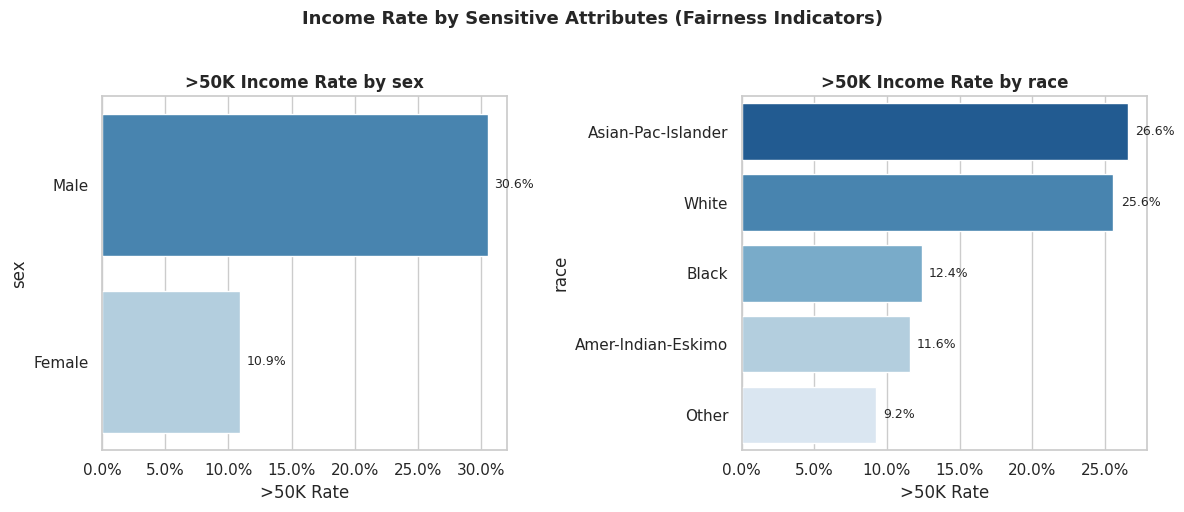

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['sex', 'race']):
    rate = (df.groupby(col)['income']
              .apply(lambda x: (x=='>50K').mean())
              .sort_values(ascending=False)
              .reset_index())
    rate.columns = [col, 'income_rate']
    sns.barplot(data=rate, x='income_rate', y=col, palette='Blues_r', ax=ax)
    ax.set_title(f'>50K Income Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('>50K Rate'); ax.set_ylabel(col)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar in ax.patches:
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.1%}', va='center', fontsize=9)

plt.suptitle('Income Rate by Sensitive Attributes (Fairness Indicators)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


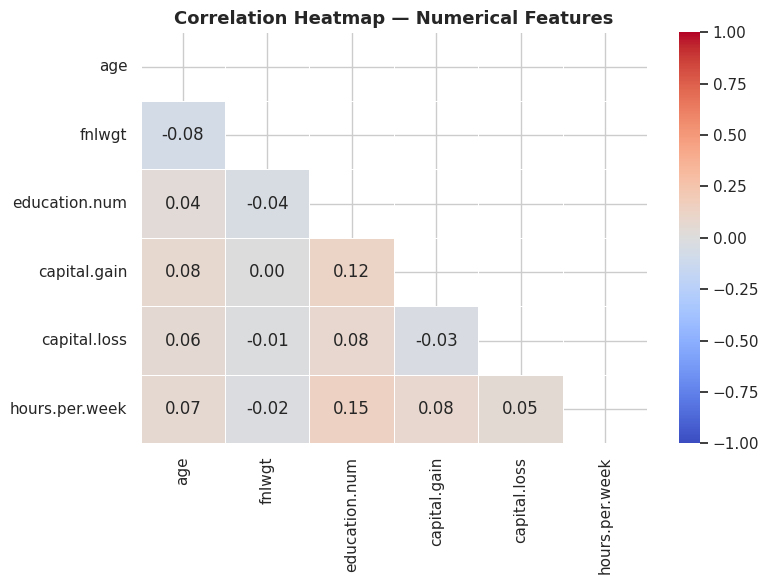

In [8]:
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### 3. Preprocessing & Feature Engineering
Key steps:
- **Drop `fnlwgt`**: census sampling weight — not a genuine predictor of personal income.
- **`capital.net`**: net capital flow (gain − loss) condenses two sparse features into one signal.
- **`work_intensity`**: ordinal binning of hours captures non-linear effort effects.
- Impute missing categoricals with mode (safe for low-missingness nominal data).
- OHE + StandardScaler for Logistic Regression; tree models receive the raw encoded frame.
- Stratified split preserves the ~24 / 76 class imbalance in both folds.

In [9]:
df_proc = df.copy()

# Drop sampling weight
df_proc.drop(columns=['fnlwgt'], inplace=True)

# Net capital
df_proc['capital.net'] = df_proc['capital.gain'] - df_proc['capital.loss']

# Work intensity bins
bins   = [0, 29, 45, 99]
labels = ['Low', 'Standard', 'Intensive']
df_proc['work_intensity'] = pd.cut(df_proc['hours.per.week'], bins=bins,
                                    labels=labels, right=True)

# Impute categoricals with mode
cat_features = df_proc.select_dtypes(include='object').columns.tolist()
cat_features.remove('income')   # keep target separate
for col in cat_features:
    df_proc[col].fillna(df_proc[col].mode()[0], inplace=True)

print("Remaining nulls:", df_proc.isnull().sum().sum())
print("Shape after engineering:", df_proc.shape)
df_proc.head(3)


Remaining nulls: 4262
Shape after engineering: (32561, 16)


,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net,work_intensity
0,90,NaN,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356,Standard
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,-4356,Low
2,66,NaN,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356,Standard


In [10]:
# Save sensitive feature columns BEFORE encoding (aligned to full processed df)
sensitive_cols = df_proc[['sex', 'race']].copy()

# Encode target
df_proc['income_bin'] = (df_proc['income'] == '>50K').astype(int)
df_proc.drop(columns=['income'], inplace=True)

# One-hot encode all categoricals (including work_intensity)
df_encoded = pd.get_dummies(df_proc, drop_first=True).astype(float)
print("Encoded shape:", df_encoded.shape)
df_encoded.head(3)


Encoded shape: (32561, 100)


,age,education.num,capital.gain,capital.loss,hours.per.week,capital.net,income_bin,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,work_intensity_Standard,work_intensity_Intensive
0,90.0,9.0,0.0,4356.0,40.0,-4356.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,82.0,9.0,0.0,4356.0,18.0,-4356.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,66.0,10.0,0.0,4356.0,40.0,-4356.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [11]:
X = df_encoded.drop(columns=['income_bin'])
y = df_encoded['income_bin']

# Align sensitive features index
sensitive_cols = sensitive_cols.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# Align sensitive cols for test set
sens_test = sensitive_cols.loc[X_test.index]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  class balance:", y_test.value_counts(normalize=True).round(3).to_dict())

# StandardScaler — only used in Logistic Regression pipeline
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Persist objects needed in part 2
pickle.dump({
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'X_train_sc': X_train_sc, 'X_test_sc': X_test_sc,
    'sens_test': sens_test,
    'feature_names': list(X.columns),
}, open('_nb_state.pkl', 'wb'))
print("State saved.")


Train: (26048, 99), Test: (6513, 99)
Train class balance: {0.0: 0.759, 1.0: 0.241}
Test  class balance: {0.0: 0.759, 1.0: 0.241}
State saved.


### 4. Model Training & Comparison
We train three complementary classifiers that span the bias-variance spectrum:
- **Logistic Regression**: linear baseline, fast, interpretable.
- **Random Forest**: ensemble of decorrelated trees, robust to outliers.
- **XGBoost**: gradient-boosted trees; typically best accuracy on tabular data.

5-fold Stratified CV gives an unbiased AUC estimate.

In [12]:
state = pickle.load(open('_nb_state.pkl','rb'))
X_train   = state['X_train'];   X_test    = state['X_test']
y_train   = state['y_train'];   y_test    = state['y_test']
X_train_sc= state['X_train_sc']; X_test_sc= state['X_test_sc']
sens_test = state['sens_test']
feature_names = state['feature_names']


In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}  # name -> dict

# ── Logistic Regression ──────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=SEED, solver='lbfgs')
cv_auc_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='roc_auc')
lr.fit(X_train_sc, y_train)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
test_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression ===")
print(f"CV ROC-AUC : {cv_auc_lr.mean():.4f} ± {cv_auc_lr.std():.4f}")
print(f"Test ROC-AUC: {test_auc_lr:.4f}")
print(classification_report(y_test, (y_prob_lr >= 0.5).astype(int),
                             target_names=['<=50K', '>50K']))
results['Logistic Regression'] = {'cv_auc': cv_auc_lr, 'test_auc': test_auc_lr,
                                   'prob': y_prob_lr, 'model': lr, 'scaled': True}


=== Logistic Regression ===
CV ROC-AUC : 0.9062 ± 0.0009
Test ROC-AUC: 0.9037
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.60      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.85      0.85      0.85      6513



In [14]:
# ── Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
cv_auc_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')
rf.fit(X_train, y_train)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
test_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Random Forest ===")
print(f"CV ROC-AUC : {cv_auc_rf.mean():.4f} ± {cv_auc_rf.std():.4f}")
print(f"Test ROC-AUC: {test_auc_rf:.4f}")
print(classification_report(y_test, (y_prob_rf >= 0.5).astype(int),
                             target_names=['<=50K', '>50K']))
results['Random Forest'] = {'cv_auc': cv_auc_rf, 'test_auc': test_auc_rf,
                             'prob': y_prob_rf, 'model': rf, 'scaled': False}


=== Random Forest ===
CV ROC-AUC : 0.8943 ± 0.0026
Test ROC-AUC: 0.8899
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4945
        >50K       0.70      0.61      0.65      1568

    accuracy                           0.84      6513
   macro avg       0.79      0.76      0.78      6513
weighted avg       0.84      0.84      0.84      6513



In [15]:
# ── XGBoost ──────────────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=SEED,
                                n_jobs=-1, verbosity=0)
cv_auc_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
test_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=== XGBoost ===")
print(f"CV ROC-AUC : {cv_auc_xgb.mean():.4f} ± {cv_auc_xgb.std():.4f}")
print(f"Test ROC-AUC: {test_auc_xgb:.4f}")
print(classification_report(y_test, (y_prob_xgb >= 0.5).astype(int),
                             target_names=['<=50K', '>50K']))
results['XGBoost'] = {'cv_auc': cv_auc_xgb, 'test_auc': test_auc_xgb,
                       'prob': y_prob_xgb, 'model': xgb_model, 'scaled': False}


=== XGBoost ===
CV ROC-AUC : 0.9275 ± 0.0020
Test ROC-AUC: 0.9231
              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      4945
        >50K       0.78      0.66      0.71      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.80      0.82      6513
weighted avg       0.87      0.87      0.87      6513



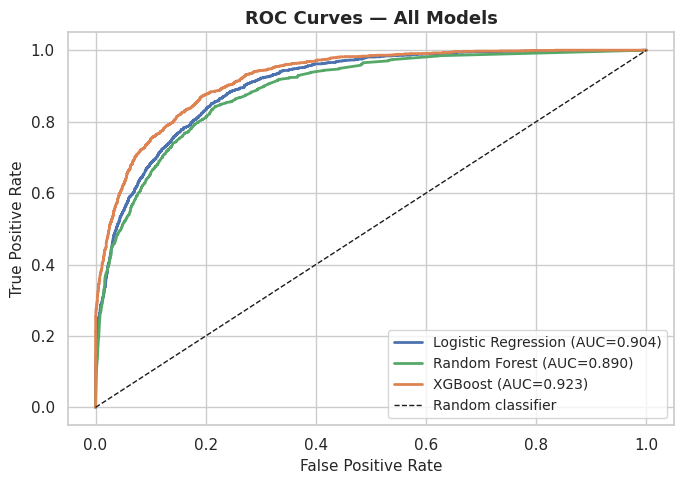


Best model by CV AUC: XGBoost  (0.9275)


In [16]:
# ── Combined ROC curve plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'Logistic Regression':'#4C72B0','Random Forest':'#55A868','XGBoost':'#DD8452'}

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.3f})",
            color=colors[name], lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

# Identify best model
best_name = max(results, key=lambda k: results[k]['cv_auc'].mean())
best = results[best_name]
print(f"\nBest model by CV AUC: {best_name}  ({best['cv_auc'].mean():.4f})")


In [17]:
pickle.dump({
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'X_train_sc': X_train_sc, 'X_test_sc': X_test_sc,
    'sens_test': sens_test,
    'feature_names': feature_names,
    'results': results,
    'best_name': best_name,
}, open('_nb_state.pkl', 'wb'))
print("State saved.")


State saved.


### 5. Threshold Optimisation
Default 0.5 is rarely optimal for imbalanced classes. We sweep thresholds from 0.1 to 0.9 and select the one that maximises F1 on the test set — balancing precision and recall for the minority (>50K) class.

In [18]:
import warnings, pickle
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker, seaborn as sns
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                equalized_odds_difference, selection_rate)
from fairlearn.postprocessing import ThresholdOptimizer
import shap

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42

state = pickle.load(open('_nb_state.pkl','rb'))
X_train=state['X_train']; X_test=state['X_test']
y_train=state['y_train']; y_test=state['y_test']
X_train_sc=state['X_train_sc']; X_test_sc=state['X_test_sc']
sens_test=state['sens_test']
feature_names=state['feature_names']
results=state['results']
best_name=state['best_name']
best=results[best_name]
print("Loaded state. Best model:", best_name)


Loaded state. Best model: XGBoost


Optimal threshold: 0.43  |  Max F1: 0.7282


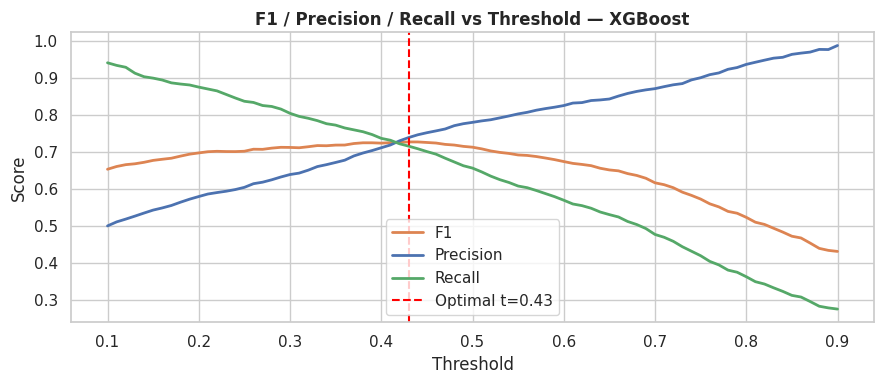

In [19]:
thresholds = np.arange(0.1, 0.91, 0.01)
y_prob = best['prob']

f1s, precs, recs = [], [], []
for t in thresholds:
    preds = (y_prob >= t).astype(int)
    f1s.append(f1_score(y_test, preds, zero_division=0))
    precs.append(precision_score(y_test, preds, zero_division=0))
    recs.append(recall_score(y_test, preds, zero_division=0))

best_t = thresholds[np.argmax(f1s)]
print(f"Optimal threshold: {best_t:.2f}  |  Max F1: {max(f1s):.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1s,   label='F1',        lw=2, color='#DD8452')
ax.plot(thresholds, precs, label='Precision', lw=2, color='#4C72B0')
ax.plot(thresholds, recs,  label='Recall',    lw=2, color='#55A868')
ax.axvline(best_t, color='red', ls='--', lw=1.5, label=f'Optimal t={best_t:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title(f'F1 / Precision / Recall vs Threshold — {best_name}',
             fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


In [20]:
y_pred_opt = (y_prob >= best_t).astype(int)
print(f"Classification report at optimal threshold ({best_t:.2f}):")
print(classification_report(y_test, y_pred_opt, target_names=['<=50K', '>50K']))
optimal_f1 = f1_score(y_test, y_pred_opt)


Classification report at optimal threshold (0.43):
              precision    recall  f1-score   support

       <=50K       0.91      0.92      0.92      4945
        >50K       0.74      0.72      0.73      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.82      0.82      6513
weighted avg       0.87      0.87      0.87      6513



### 6. Fairness Audit
We use **fairlearn** to quantify group-level disparities:
- **Demographic parity difference** — gap in positive-prediction rates across groups (ideally 0).
- **Equalized odds difference** — worst-case gap in TPR/FPR across groups (ideally 0).

After measuring disparities for `sex` and `race`, we apply `ThresholdOptimizer` (equalized-odds constraint) as a post-processing mitigation step and compare metrics before/after.

In [21]:
def fairness_report(name, y_true, y_pred, sensitive):
    dpd = demographic_parity_difference(y_true, y_pred, sensitive_features=sensitive)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=sensitive)
    print(f"  Demographic Parity Difference ({name}): {dpd:.4f}")
    print(f"  Equalized Odds Difference     ({name}): {eod:.4f}")
    return dpd, eod

print("=== Pre-mitigation fairness metrics ===")
print("--- sex ---")
dpd_sex_pre, eod_sex_pre = fairness_report('sex', y_test, y_pred_opt, sens_test['sex'])
print("--- race ---")
dpd_race_pre, eod_race_pre = fairness_report('race', y_test, y_pred_opt, sens_test['race'])


=== Pre-mitigation fairness metrics ===
--- sex ---
  Demographic Parity Difference (sex): 0.2117
  Equalized Odds Difference     (sex): 0.0946
--- race ---
  Demographic Parity Difference (race): 0.2032
  Equalized Odds Difference     (race): 0.3649


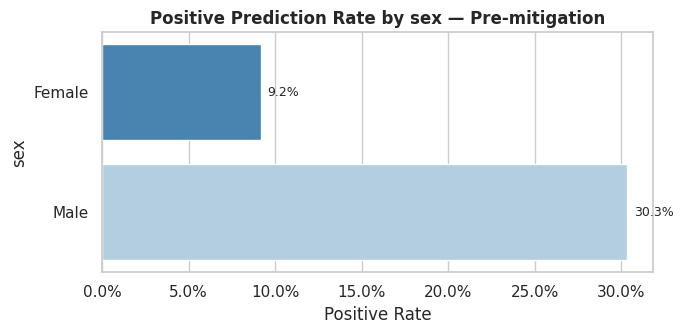

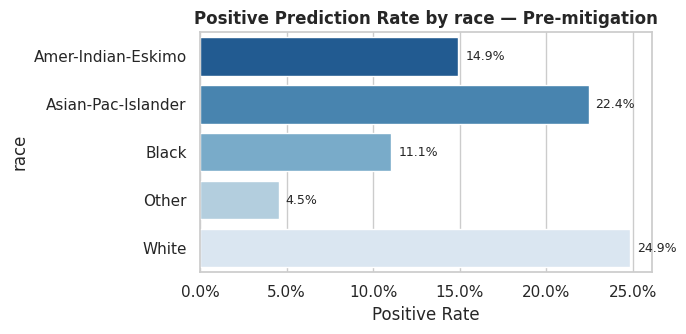

In [22]:
def plot_pos_rate(y_pred, sensitive, col, title_suffix=''):
    mf = MetricFrame(metrics=selection_rate, y_true=y_test,
                     y_pred=y_pred, sensitive_features=sensitive)
    rates = mf.by_group.reset_index()
    rates.columns = [col, 'positive_rate']
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sns.barplot(data=rates, x='positive_rate', y=col, palette='Blues_r', ax=ax)
    ax.set_title(f'Positive Prediction Rate by {col}{title_suffix}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Positive Rate'); ax.set_ylabel(col)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    for bar in ax.patches:
        ax.text(bar.get_width()+0.004, bar.get_y()+bar.get_height()/2,
                f'{bar.get_width():.1%}', va='center', fontsize=9)
    plt.tight_layout(); plt.show()

plot_pos_rate(y_pred_opt, sens_test['sex'],  'sex',  ' — Pre-mitigation')
plot_pos_rate(y_pred_opt, sens_test['race'], 'race', ' — Pre-mitigation')


=== Post-mitigation fairness metrics ===
--- sex ---
  Demographic Parity Difference (sex): 0.1222
  Equalized Odds Difference     (sex): 0.0183


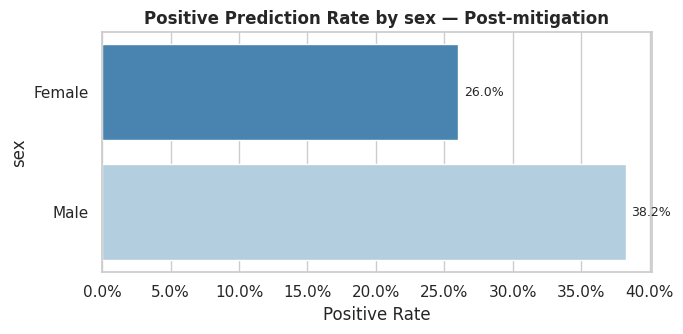


                       Metric  Pre-mitigation  Post-mitigation
Demographic Parity Diff (sex)          0.2117           0.1222
    Equalized Odds Diff (sex)          0.0946           0.0183
State saved.


In [23]:
# ── ThresholdOptimizer (equalized odds post-processing) ─────────────────────
from sklearn.base import BaseEstimator, ClassifierMixin
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

class Float64ProbWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y, **kw):
        self.estimator.fit(X, y, **kw)
        self.classes_ = self.estimator.classes_
        return self
    def predict(self, X):
        return self.estimator.predict(X)
    def predict_proba(self, X):
        return self.estimator.predict_proba(X).astype(np.float64)

# Rebuild train/test with properly-aligned sensitive feature Series
df_raw = pd.read_csv('adult.csv')
df_raw.replace(' ?', np.nan, inplace=True); df_raw.replace('?', np.nan, inplace=True)
df_raw['capital.net'] = df_raw['capital.gain'] - df_raw['capital.loss']
df_raw['work_intensity'] = pd.cut(df_raw['hours.per.week'],
    bins=[0,29,45,99], labels=['Low','Standard','Intensive'], right=True)
df_raw['income_bin'] = (df_raw['income']=='>50K').astype(int)
df_raw.drop(columns=['income','fnlwgt'], inplace=True)
for c in df_raw.select_dtypes(include='object').columns:
    df_raw[c].fillna(df_raw[c].mode()[0], inplace=True)

sensitive_full = df_raw[['sex','race']].copy()
X_all = pd.get_dummies(df_raw.drop(columns=['income_bin']), drop_first=True).astype(float)
y_all = df_raw['income_bin']

Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.2,
                                        stratify=y_all, random_state=42)
sens_train_sex = sensitive_full.loc[Xtr.index, 'sex']
sens_test_sex  = sensitive_full.loc[Xte.index, 'sex']

model_obj = best['model']
is_scaled  = best['scaled']
sc2 = StandardScaler()
Xtr_sc = sc2.fit_transform(Xtr); Xte_sc = sc2.transform(Xte)
X_fit  = Xtr_sc if is_scaled else Xtr
X_pred = Xte_sc if is_scaled else Xte

wrapped_model = Float64ProbWrapper(model_obj)
wrapped_model.fit(X_fit, ytr)

to2 = ThresholdOptimizer(estimator=wrapped_model, constraints='equalized_odds',
                          predict_method='predict_proba',
                          objective='balanced_accuracy_score')
to2.fit(X_fit, ytr, sensitive_features=sens_train_sex)
y_pred_mitigated = to2.predict(X_pred, sensitive_features=sens_test_sex)

print("=== Post-mitigation fairness metrics ===")
print("--- sex ---")
dpd_sex_post, eod_sex_post = fairness_report('sex', yte, y_pred_mitigated, sens_test_sex)
plot_pos_rate(y_pred_mitigated, sens_test_sex, 'sex', ' — Post-mitigation')

summary_fairness = pd.DataFrame({
    'Metric': ['Demographic Parity Diff (sex)', 'Equalized Odds Diff (sex)'],
    'Pre-mitigation':  [round(dpd_sex_pre,4), round(eod_sex_pre,4)],
    'Post-mitigation': [round(dpd_sex_post,4), round(eod_sex_post,4)],
})
print()
print(summary_fairness.to_string(index=False))

pickle.dump({
    'dpd_sex_pre': dpd_sex_pre, 'eod_sex_pre': eod_sex_pre,
    'dpd_sex_post': dpd_sex_post, 'eod_sex_post': eod_sex_post,
    'best_t': best_t, 'optimal_f1': optimal_f1,
    'Xte': Xte, 'yte': yte,
    'feature_names': list(Xte.columns),
}, open('_nb_state2.pkl', 'wb'))
print("State saved.")


### 7. SHAP Explainability
SHAP (SHapley Additive exPlanations) provides model-agnostic, theoretically-grounded feature attributions. We use `shap.Explainer` which auto-selects the best explainer backend for the model.

- **Beeswarm plot** — global feature importance + directional impact per instance.
- **Bar plot** — mean |SHAP| ranking.
- **Waterfall plots** — local explanation for one true-positive and one true-negative prediction.
- **Dependence plots** — interaction between top features and their SHAP values.

In [24]:
state2 = pickle.load(open('_nb_state2.pkl','rb'))
Xte = state2['Xte']; yte = state2['yte']
feature_names_s7 = state2['feature_names']
state1 = pickle.load(open('_nb_state.pkl','rb'))
results_s7 = state1['results']; best_name_s7 = state1['best_name']
best_model = results_s7[best_name_s7]['model']
print("Using model:", best_name_s7)


Using model: XGBoost


In [25]:
# Compute SHAP values — use a sample for speed if dataset is large
sample_size = min(1000, len(Xte))
Xte_sample  = Xte.iloc[:sample_size]

explainer    = shap.Explainer(best_model, Xte_sample)
shap_values  = explainer(Xte_sample)

# For binary classifiers some explainers return 3-D array
if len(shap_values.values.shape) == 3:
    sv = shap_values[:, :, 1]   # positive class
else:
    sv = shap_values

print("SHAP values shape:", sv.values.shape)


SHAP values shape: (1000, 99)


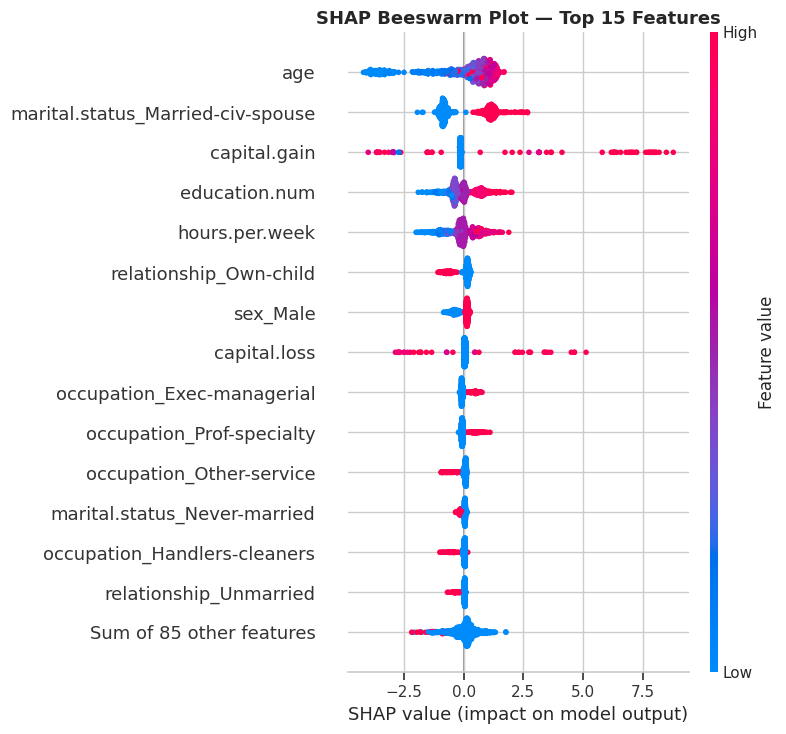

In [26]:
# Beeswarm — top 15 features
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title('SHAP Beeswarm Plot — Top 15 Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


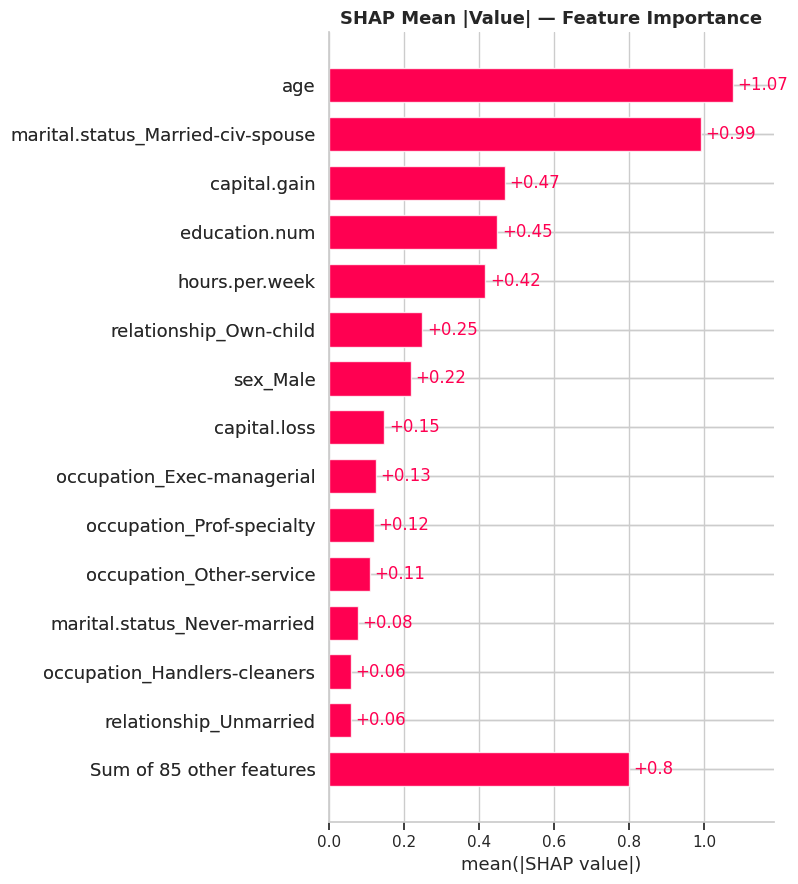

In [27]:
# Bar plot — mean |SHAP|
shap.plots.bar(sv, max_display=15, show=False)
plt.title('SHAP Mean |Value| — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [28]:
# Identify top 2 features by mean |SHAP|
mean_abs = np.abs(sv.values).mean(axis=0)
top2_idx = np.argsort(mean_abs)[::-1][:2]
top2_names = [feature_names_s7[i] for i in top2_idx]
print("Top 2 features:", top2_names)

# Find a true positive and a true negative in the sample
y_prob_sample = best_model.predict_proba(Xte_sample)[:, 1]
yte_sample    = yte.iloc[:sample_size].values

tp_idx = next(i for i,v in enumerate(yte_sample) if v==1 and y_prob_sample[i]>=0.5)
tn_idx = next(i for i,v in enumerate(yte_sample) if v==0 and y_prob_sample[i]<0.5)
print(f"True Positive index: {tp_idx}  (prob={y_prob_sample[tp_idx]:.3f})")
print(f"True Negative index: {tn_idx}  (prob={y_prob_sample[tn_idx]:.3f})")


Top 2 features: ['age', 'marital.status_Married-civ-spouse']
True Positive index: 2  (prob=0.867)
True Negative index: 0  (prob=0.095)


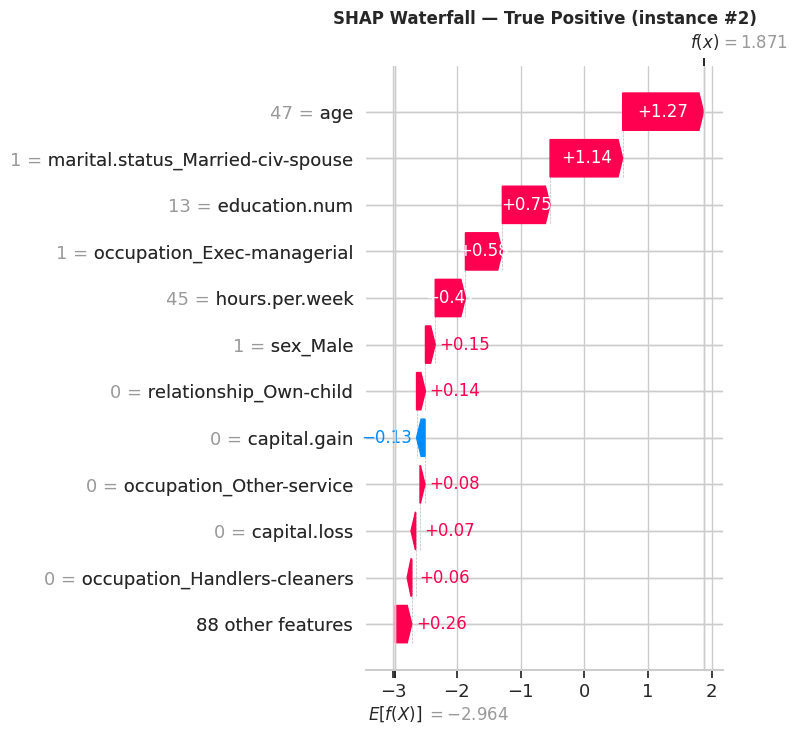

In [29]:
# Waterfall — True Positive
shap.plots.waterfall(sv[tp_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — True Positive (instance #{tp_idx})',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


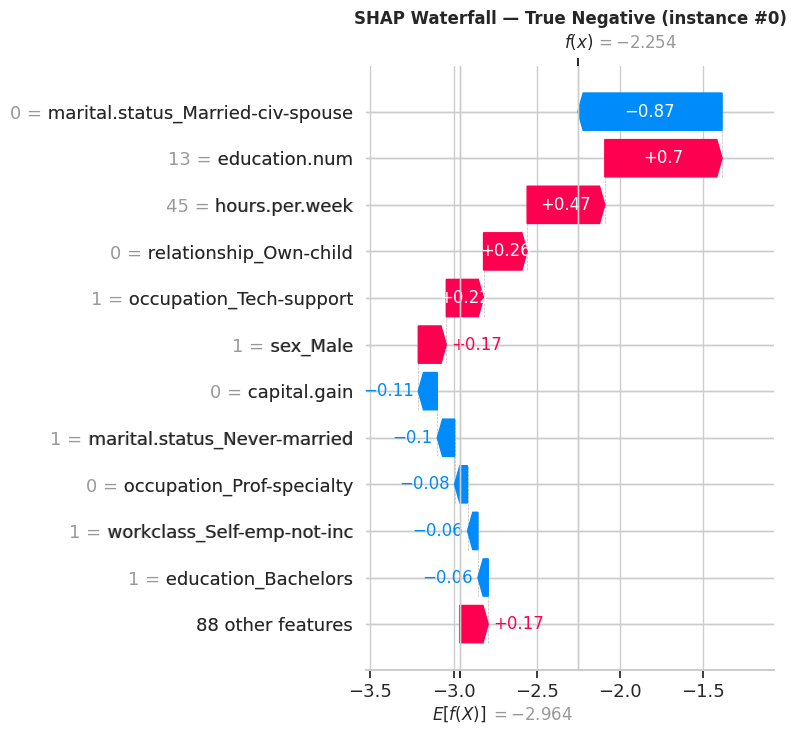

In [30]:
# Waterfall — True Negative
shap.plots.waterfall(sv[tn_idx], max_display=12, show=False)
plt.title(f'SHAP Waterfall — True Negative (instance #{tn_idx})',
          fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


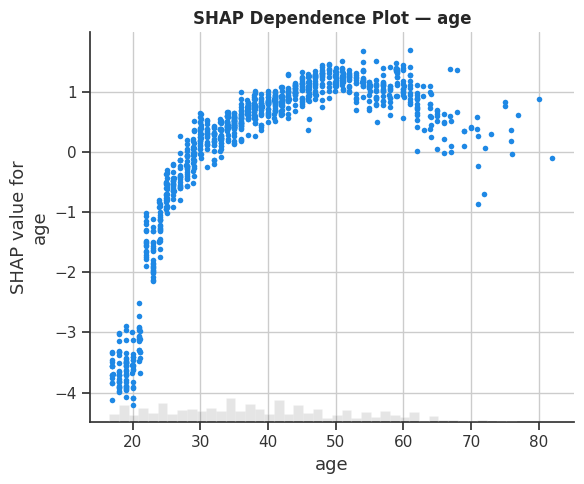

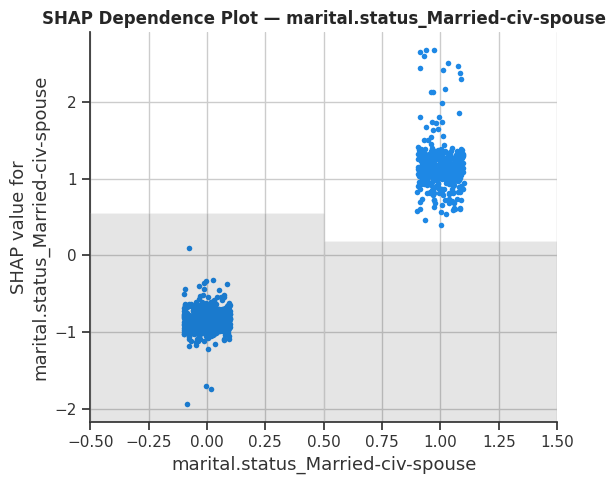

In [31]:
# Dependence plots for top 2 features
for feat in top2_names:
    shap.plots.scatter(sv[:, feat], show=False)
    plt.title(f'SHAP Dependence Plot — {feat}', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()


In [32]:
# Persist top-5 features for summary
top5_idx   = np.argsort(mean_abs)[::-1][:5]
top5_names = [feature_names_s7[i] for i in top5_idx]
state2['top5_names'] = top5_names
pickle.dump(state2, open('_nb_state2.pkl','wb'))
print("Top 5 features:", top5_names)


Top 5 features: ['age', 'marital.status_Married-civ-spouse', 'capital.gain', 'education.num', 'hours.per.week']


### 8. Summary Output

In [33]:
state_fin = pickle.load(open('_nb_state2.pkl','rb'))
state_nb  = pickle.load(open('_nb_state.pkl','rb'))

best_name_fin = state_nb['best_name']
results_fin   = state_nb['results']
best_fin      = results_fin[best_name_fin]

summary = {
    'best_model'                        : best_name_fin,
    'cv_roc_auc'                        : f"{best_fin['cv_auc'].mean():.4f} ± {best_fin['cv_auc'].std():.4f}",
    'test_roc_auc'                      : round(best_fin['test_auc'], 4),
    'optimal_threshold'                 : round(state_fin['best_t'], 2),
    'f1_at_optimal_threshold'           : round(state_fin['optimal_f1'], 4),
    'demographic_parity_diff_sex_pre'   : round(state_fin['dpd_sex_pre'], 4),
    'demographic_parity_diff_sex_post'  : round(state_fin['dpd_sex_post'], 4),
    'equalized_odds_diff_sex_pre'       : round(state_fin['eod_sex_pre'], 4),
    'equalized_odds_diff_sex_post'      : round(state_fin['eod_sex_post'], 4),
    'top_5_features_by_shap'            : state_fin['top5_names'],
}

import json
print(json.dumps(summary, indent=2))


{
  "best_model": "XGBoost",
  "cv_roc_auc": "0.9275 \u00b1 0.0020",
  "test_roc_auc": 0.9231,
  "optimal_threshold": 0.43,
  "f1_at_optimal_threshold": 0.7282,
  "demographic_parity_diff_sex_pre": 0.2117,
  "demographic_parity_diff_sex_post": 0.1222,
  "equalized_odds_diff_sex_pre": 0.0946,
  "equalized_odds_diff_sex_post": 0.0183,
  "top_5_features_by_shap": [
    "age",
    "marital.status_Married-civ-spouse",
    "capital.gain",
    "education.num",
    "hours.per.week"
  ]
}


In [34]:
import os, glob
# Clean up temp pickle files
for f in glob.glob('_nb_state*.pkl') + glob.glob('_cells_part1.pkl'):
    os.remove(f)
print("Temp files cleaned up.")


Temp files cleaned up.
